In [1]:
import glob
import torch
from anomalib.metrics import AUROC, PRO, AUPRO
import matplotlib.pyplot as plt

In [2]:
folder_path = "metrics/wood/hole" + "/*"

In [3]:
prompts = []
im_auroc = {}
pix_auroc = {}
aupro = {}

for filename in sorted(glob.glob(folder_path)):
        x = filename.split('\\')
        x = x[-1].split('.')
        x = x[0]
        print(x)
        prompts.append(x)
        res = torch.load(filename, weights_only=False)
        im_auroc[x] = res["image_auroc"]
        pix_auroc[x] = res["pixel_auroc"]
        aupro[x] = res["aupro"]

broken
crack
damage
damaged
drilled_hole
error
hole


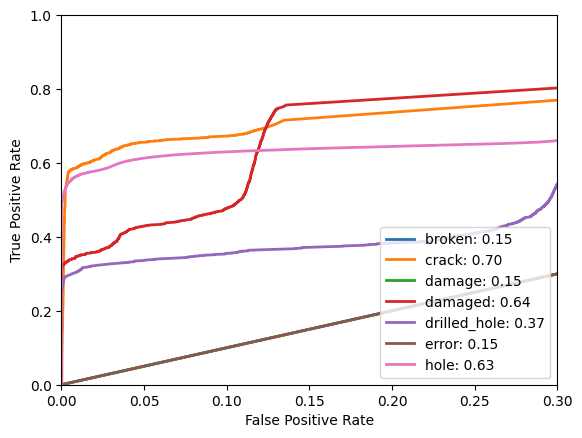

In [ ]:
xlim = (0.0, 1.0)
ylim = (0.0, 1.0)

'''
for key in im_auroc:
    value = im_auroc[key]
    fpr, tpr = value._compute()
    auroc = value.compute()

    xlim = (0.0, 1.0)
    ylim = (0.0, 1.0)

for key in pix_auroc:
    value = pix_auroc[key]
    fpr, tpr = value._compute()
    auroc = value.compute()

    xlim = (0.0, 1.0)
    ylim = (0.0, 1.0)
'''
aupro_fig, aupro_axs = plt.subplots()
    
for key in aupro:
    value = aupro[key]
    fpr, tpr = value._compute()
    aupro_ = value.compute()
    xlim = (0.0, float(value.fpr_limit.detach().cpu().item()))
    
    aupro_axs.plot(
        fpr.detach().cpu(),
        tpr.detach().cpu(),
        #color="darkorange",
        figure=aupro_fig,
        lw=2,
        label=f"{key}: {aupro_.detach().cpu():0.2f}",
    )
aupro_axs.set_xlim(xlim)
aupro_axs.set_ylim(ylim)
aupro_axs.set_xlabel("False Positive Rate")
aupro_axs.set_ylabel("True Positive Rate")
aupro_axs.legend(loc="lower right")       